In [60]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as snl 
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split


In [61]:
df = pd.read_csv('titanic_data_updated.csv')
display(df)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,no,third,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,yes,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,yes,third,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,yes,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,no,third,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,no,second,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,yes,first,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,no,third,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,yes,first,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    object 
 2   Pclass       891 non-null    object 
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(3), object(7)
memory usage: 83.7+ KB


In [63]:
df.describe()

,PassengerId,Age,SibSp,Parch,Fare
count,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,29.699118,0.523008,0.381594,32.204208
std,257.353842,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,38.000000,1.000000,0.000000,31.000000
max,891.000000,80.000000,8.000000,6.000000,512.329200


In [64]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,no,third,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,yes,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,yes,third,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,yes,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,no,third,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,no,second,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,yes,first,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,no,third,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,yes,first,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [65]:
df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,no,third,male,22.0,1,0,7.2500,S
1,yes,first,female,38.0,1,0,71.2833,C
2,yes,third,female,26.0,0,0,7.9250,S
3,yes,first,female,35.0,1,0,53.1000,S
4,no,third,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,no,second,male,27.0,0,0,13.0000,S
887,yes,first,female,19.0,0,0,30.0000,S
888,no,third,female,NaN,1,2,23.4500,S
889,yes,first,male,26.0,0,0,30.0000,C


In [66]:
df.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

<Axes: xlabel='Age', ylabel='Density'>

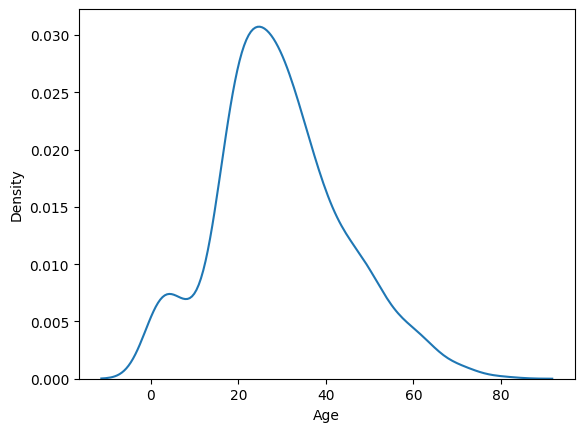

In [67]:
snl.kdeplot(data=df['Age'])

In [68]:
age_mean = df['Age'].mean()
age_mean

np.float64(29.69911764705882)

In [69]:
age_median = df['Age'].median()
age_median

np.float64(28.0)

In [70]:
x = df.drop(['Survived'], axis=1)
y = df['Survived']
display(x)
display(y)

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,third,male,22.0,1,0,7.2500,S
1,first,female,38.0,1,0,71.2833,C
2,third,female,26.0,0,0,7.9250,S
3,first,female,35.0,1,0,53.1000,S
4,third,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...
886,second,male,27.0,0,0,13.0000,S
887,first,female,19.0,0,0,30.0000,S
888,third,female,NaN,1,2,23.4500,S
889,first,male,26.0,0,0,30.0000,C


0       no
1      yes
2      yes
3      yes
4       no
      ... 
886     no
887    yes
888     no
889    yes
890     no
Name: Survived, Length: 891, dtype: object

In [71]:
x.isnull().sum()

Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

In [72]:
y.isnull().sum()

np.int64(0)

In [74]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [75]:
x_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
331,first,male,45.5,0,0,28.5000,S
733,second,male,23.0,0,0,13.0000,S
382,third,male,32.0,0,0,7.9250,S
704,third,male,26.0,1,0,7.8542,S
813,third,female,6.0,4,2,31.2750,S
...,...,...,...,...,...,...,...
106,third,female,21.0,0,0,7.6500,S
270,first,male,NaN,0,0,31.0000,S
860,third,male,41.0,2,0,14.1083,S
435,first,female,14.0,1,2,120.0000,S


In [76]:
x_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
709,third,male,NaN,1,1,15.2458,C
439,second,male,31.0,0,0,10.5000,S
840,third,male,20.0,0,0,7.9250,S
720,second,female,6.0,0,1,33.0000,S
39,third,female,14.0,1,0,11.2417,C
...,...,...,...,...,...,...,...
433,third,male,17.0,0,0,7.1250,S
773,third,male,NaN,0,0,7.2250,C
25,third,female,38.0,1,5,31.3875,S
84,second,female,17.0,0,0,10.5000,S


In [77]:
y_train

331     no
733     no
382     no
704     no
813     no
      ... 
106    yes
270     no
860     no
435    yes
102     no
Name: Survived, Length: 712, dtype: object

In [78]:
y_test

709    yes
439     no
840     no
720    yes
39     yes
      ... 
433     no
773     no
25     yes
84     yes
10     yes
Name: Survived, Length: 179, dtype: object

In [79]:
x_train.isnull().sum()

Pclass        0
Sex           0
Age         140
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

In [80]:
y_train.isnull().sum()

np.int64(0)

In [81]:
age_mean 
age_median 

np.float64(28.0)